In [32]:
import glob
import re
import numpy as np
import xarray as xr
import pandas as pd
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.dates as mdates
# geopandas extends pandas to handle geospatial data and perform operations on geographic shapes.
import geopandas as gpd
# matplotlib.colors provides tools to define and manipulate colormaps for visualizations.
import matplotlib.colors as mcolors
# ListedColormap allows the creation of custom colormaps for visualizations.
from matplotlib.colors import ListedColormap
import matplotlib.patheffects as patheffects

In [6]:

# Fixed base directory
base_dir = "/home/jovyan/SAMBBA_data/dap.ceda.ac.uk/badc/faam/data/2012"

# List of target subdirectories
dirs = [
    "b732-sep-15", "b733-sep-16", 
    "b734-sep-18", "b735-sep-19", "b736-sep-19", "b737-sep-20", "b738-sep-22", 
    "b739-sep-23", "b742-sep-27", "b743-sep-27", 
    "b744-sep-28", "b745-sep-28", "b746-sep-29", "b748-oct-02", 
    "b749-oct-03", 
]


In [7]:
# Initialize a list to store file paths
file_paths = []

# Iterate over each directory and collect .nc files from 'core_processed'
for d in dirs:
    path = f"{base_dir}/{d}/core_processed/core_faam*r1*.nc"
    file_paths.extend(sorted(glob.glob(path)))

# List to store filtered file paths
filtered_files = []

# Iterate over each directory and collect .nc files from 'core_processed'
for d in dirs:
    path = f"{base_dir}/{d}/core_processed/core_faam*r1*.nc"
    all_files = sorted(glob.glob(path))  # Get all r1 files
    
    # Print files found for debugging
    #print(f"Files found in {path}:")
    #print(all_files)
    
    # Filter out files that contain "_1hz"
    for file in all_files:
        if "_1hz" not in file:  # Exclude _1hz files
            filtered_files.append(file)

# Initialize a list to store file paths
file_paths_ams = []

# Iterate over each directory and collect .nc files from 'core_processed'
for d in dirs:
    path = f"{base_dir}/{d}/non-core/man-ams*.na"
    file_paths_ams.extend(sorted(glob.glob(path)))

# Initialize a list to store file paths
file_paths_sp2 = []

# Iterate over each directory and collect .nc files from 'core_processed'
for d in dirs:
    path = f"{base_dir}/{d}/non-core/man-sp2*.na"
    file_paths_sp2.extend(sorted(glob.glob(path)))

# Initialize a list to store file paths
file_paths_dry_neph = []

# Iterate over each directory and collect .nc files from 'core_processed'
for d in dirs:
    path = f"{base_dir}/{d}/mo-non-core/metoffice*neph1*.nc"
    file_paths_dry_neph.extend(sorted(glob.glob(path)))


# Initialize a list to store file paths
file_paths_dry_neph = []

# Iterate over each directory and collect .nc files from 'core_processed'
for d in dirs:
    path = f"{base_dir}/{d}/mo-non-core/metoffice*neph1*.nc"
    file_paths_dry_neph.extend(sorted(glob.glob(path)))

# Initialize a list to store file paths
file_paths_flight_sum = []

# Iterate over each directory and collect .nc files from 'core_processed'
for d in dirs:
    path = f"{base_dir}/{d}/flight-sum*.txt"
    file_paths_flight_sum.extend(sorted(glob.glob(path)))

In [8]:
# Function to extract flight number (e.g., "b734") from a file path
def extract_flight_number(file_path):
    match = re.search(r'b\d{3}', file_path)
    return match.group(0) if match else None  # Returns None if no match

# Get flight numbers for each dataset
flights_nc = {extract_flight_number(f) for f in filtered_files}
flights_ams = {extract_flight_number(f) for f in file_paths_ams}
flights_sp2 = {extract_flight_number(f) for f in file_paths_sp2}
flights_neph = {extract_flight_number(f) for f in file_paths_dry_neph}
flights_sum = {extract_flight_number(f) for f in file_paths_flight_sum}

# Find flights that are in all three datasets
common_flights = flights_nc & flights_ams & flights_sp2 & flights_neph & flights_sum # Set intersection

# Filter the file lists to include only matching flights
filtered_nc = [f for f in filtered_files if extract_flight_number(f) in common_flights]
filtered_ams = [f for f in file_paths_ams if extract_flight_number(f) in common_flights]
filtered_sp2 = [f for f in file_paths_sp2 if extract_flight_number(f) in common_flights]
filtered_neph = [f for f in file_paths_dry_neph if extract_flight_number(f) in common_flights]
filtered_sum = [f for f in file_paths_flight_sum if extract_flight_number(f) in common_flights]

# Print the results
print(f"Common flights: {sorted(common_flights)}")
print(f"Filtered NC files: {len(filtered_nc)}")
print(f"Filtered AMS files: {len(filtered_ams)}")
print(f"Filtered SP2 files: {len(filtered_sp2)}")
print(f"Filtered Neph files: {len(filtered_sp2)}")
print(f"Filtered Flight sum files: {len(filtered_sum)}")

filtered_sp2[0]

# Extract the date (format: yyyymmdd)
match = re.search(r'(\d{8})', filtered_sp2[0])

# Get the matched date or None if not found
flight_date = match.group(1) if match else None

print(flight_date)  # Output: 20120914

Common flights: ['b734', 'b737', 'b739', 'b742', 'b743', 'b744', 'b745', 'b746', 'b748', 'b749']
Filtered NC files: 10
Filtered AMS files: 10
Filtered SP2 files: 10
Filtered Neph files: 10
Filtered Flight sum files: 10
20120918


In [38]:
def var_plot_landcover():
    # Open the dataset
    # Load the satellite dataset (e.g., MODIS data) using xarray. The dataset is in HDF format, 
    # so the "netcdf4" engine is specified to handle the file correctly.
    ds = xr.open_dataset('../MCD12C1.A2013001.061.2022165063153.hdf', engine="netcdf4")
    #MCD12C1.A2012001.061.2022162172724.hdf
    
    # Sort the Y-axis in descending order
    ds = ds.sortby("YDim:MOD12C1", ascending=False)
    
    # Generate latitude and longitude arrays
    # Create a latitude array with values ranging from -90 to 90, evenly spaced for 3600 points.
    # This corresponds to the number of points along the YDim:MOD12C1 dimension of the dataset.
    latitude = np.linspace(-90, 90, 3600)  # For YDim:MOD12C1
    
    # Create a longitude array with values ranging from -180 to 180, evenly spaced for 7200 points.
    # This corresponds to the number of points along the XDim:MOD12C1 dimension of the dataset.
    longitude = np.linspace(-180, 180, 7200)  # For XDim:MOD12C1
    
    # Assign latitude and longitude as coordinates with explicit dimensions
    # Use the `assign_coords` method to add the generated latitude and longitude arrays
    # as coordinates to the dataset. The "latitude" array is tied to the YDim:MOD12C1 dimension,
    # and the "longitude" array is tied to the XDim:MOD12C1 dimension.
    ds = ds.assign_coords({
        "latitude": ("YDim:MOD12C1", latitude), 
        "longitude": ("XDim:MOD12C1", longitude)
    })
    
    # Replace the existing dimensions with the newly assigned coordinates
    # The `swap_dims` method is used to replace the YDim:MOD12C1 dimension with "latitude"
    # and the XDim:MOD12C1 dimension with "longitude". This makes the dataset directly indexable
    # using latitude and longitude values instead of the original dimension labels.
    ds = ds.swap_dims({"YDim:MOD12C1": "latitude", "XDim:MOD12C1": "longitude"})
    
    
    # Define the bounding box coordinates for a region of interest
    # These coordinates specify the minimum and maximum longitude (minlon, maxlon)
    # and latitude (minlat, maxlat) for the region you want to extract from the dataset.
    
    # Box 1: The bounding box covers a specific region in the Amazon area
    #minlon, maxlon, minlat, maxlat = -72, -48, -11, -3  # Example box 1
    minlon, maxlon, minlat, maxlat = -66.5, -45.5, -12, -6  # Example box 2
    # ax3.set_extent([-66.5, -45.5, -12, -6], crs=ccrs.PlateCarree())
    
    ds_subset = ds.sel(
        latitude=slice(minlat, maxlat),  # Latitude slicing (descending order)
        longitude=slice(minlon, maxlon)  # Longitude slicing (ascending order)
    )
    
    # Define the land cover classes and their corresponding descriptive names
    # Each key in the dictionary represents a class number, and its value is the name of the land cover type.
    land_cover_classes = {
        0: "Water",
        1: "Evergreen Needleleaf Forest",
        2: "Evergreen Broadleaf Forest",
        3: "Deciduous Needleleaf Forest",
        4: "Deciduous Broadleaf Forest",
        5: "Mixed Forests",
        6: "Closed Shrubland",
        7: "Open Shrublands",
        8: "Woody Savannas",
        9: "Savannas",
        10: "Grasslands",
        11: "Permanent Wetlands",
        12: "Croplands",
        13: "Urban and Built-Up",
        14: "Cropland/Natural Vegetation Mosaic",
        15: "Snow and Ice",
        16: "Barren or Sparsely Vegetated",
    }
    
    # Define a list of custom colors corresponding to the land cover classes
    # These colors will be used in the plot to represent each class visually.
    custom_colors = [
        "blue",         # 0: Water
        "darkgreen",    # 1: Evergreen Needleleaf Forest
        "limegreen",    # 2: Evergreen Broadleaf Forest
        "yellowgreen",  # 3: Deciduous Needleleaf Forest
        "olivedrab",    # 4: Deciduous Broadleaf Forest
        "olive",        # 5: Mixed Forests
        "brown",        # 6: Closed Shrubland
        "peru",         # 7: Open Shrublands
        "tan",          # 8: Woody Savannas
        "khaki",        # 9: Savannas
        "gold",         # 10: Grasslands
        "aqua",         # 11: Permanent Wetlands
        "orange",       # 12: Croplands
        "red",          # 13: Urban and Built-Up
        "teal",         # 14: Cropland/Natural Vegetation Mosaic
        "white",        # 15: Snow and Ice
        "gray"          # 16: Barren or Sparsely Vegetated
    ]
    
    # Create a colormap using the custom colors
    # The colormap maps the land cover classes to the corresponding colors for visualization.
    custom_cmap = ListedColormap(custom_colors)
    
    # Define a normalization that maps class numbers to colors in the colormap
    # BoundaryNorm ensures the colors align correctly with the class boundaries.
    num_classes = len(land_cover_classes)  # Total number of land cover classes
    cmap = custom_cmap
    norm = mcolors.BoundaryNorm(
        boundaries=np.arange(-0.5, len(custom_colors) + 0.5, 1),  # Boundaries between classes
        ncolors=len(custom_colors)  # Total number of colors
    )
    
    # Define the classes that appear on the map (optional)
    # This is useful if not all classes are present in the region being plotted.
    active_classes = [0, 2, 4, 5, 8, 9, 10, 11, 12, 13]  # Example subset of active classes
    
    # Filter the land cover classes to include only the active classes
    # This creates a smaller dictionary with just the classes that are present.
    filtered_land_cover_classes = {k: land_cover_classes[k] for k in active_classes}
    #print(filtered_land_cover_classes)
    
    # Filter the colors to match the active classes
    # This ensures that the colormap contains only the colors for the active classes.
    filtered_colors = [custom_colors[k] for k in active_classes]
    #print(filtered_colors)
    
    # Create a new colormap using the filtered colors
    # The new colormap will include only the colors corresponding to the active classes.
    filtered_cmap = ListedColormap(filtered_colors)
    #print(filtered_cmap)
    
    # Update the normalization to match the filtered classes
    # This ensures that the color mapping aligns with the filtered colormap.
    norm2 = mcolors.BoundaryNorm(
        boundaries=np.arange(0, len(filtered_colors), 1),  # Adjust boundaries to the filtered classes
        ncolors=len(filtered_colors)  # Total number of filtered colors
    )

    # Define the file paths for shapefiles that contain geographical data
    cities_shapefile = "/home/jovyan/GOES-Fire-Inventory/Auxiliary Data/ne_10m_populated_places.shp"  # Cities shapefile
    roads_shapefile = "/home/jovyan/GOES-Fire-Inventory/Auxiliary Data/ne_10m_roads.shp"
    #"../GOES-Fire-Inventory/
    # Read the shapefiles for cities, roads, and urban areas into GeoDataFrames
    cities = gpd.read_file(cities_shapefile)
    roads = gpd.read_file(roads_shapefile)
    
    return minlon,maxlon,minlat,maxlat,roads,cities,ds_subset,cmap,norm,filtered_colors,filtered_land_cover_classes,active_classes

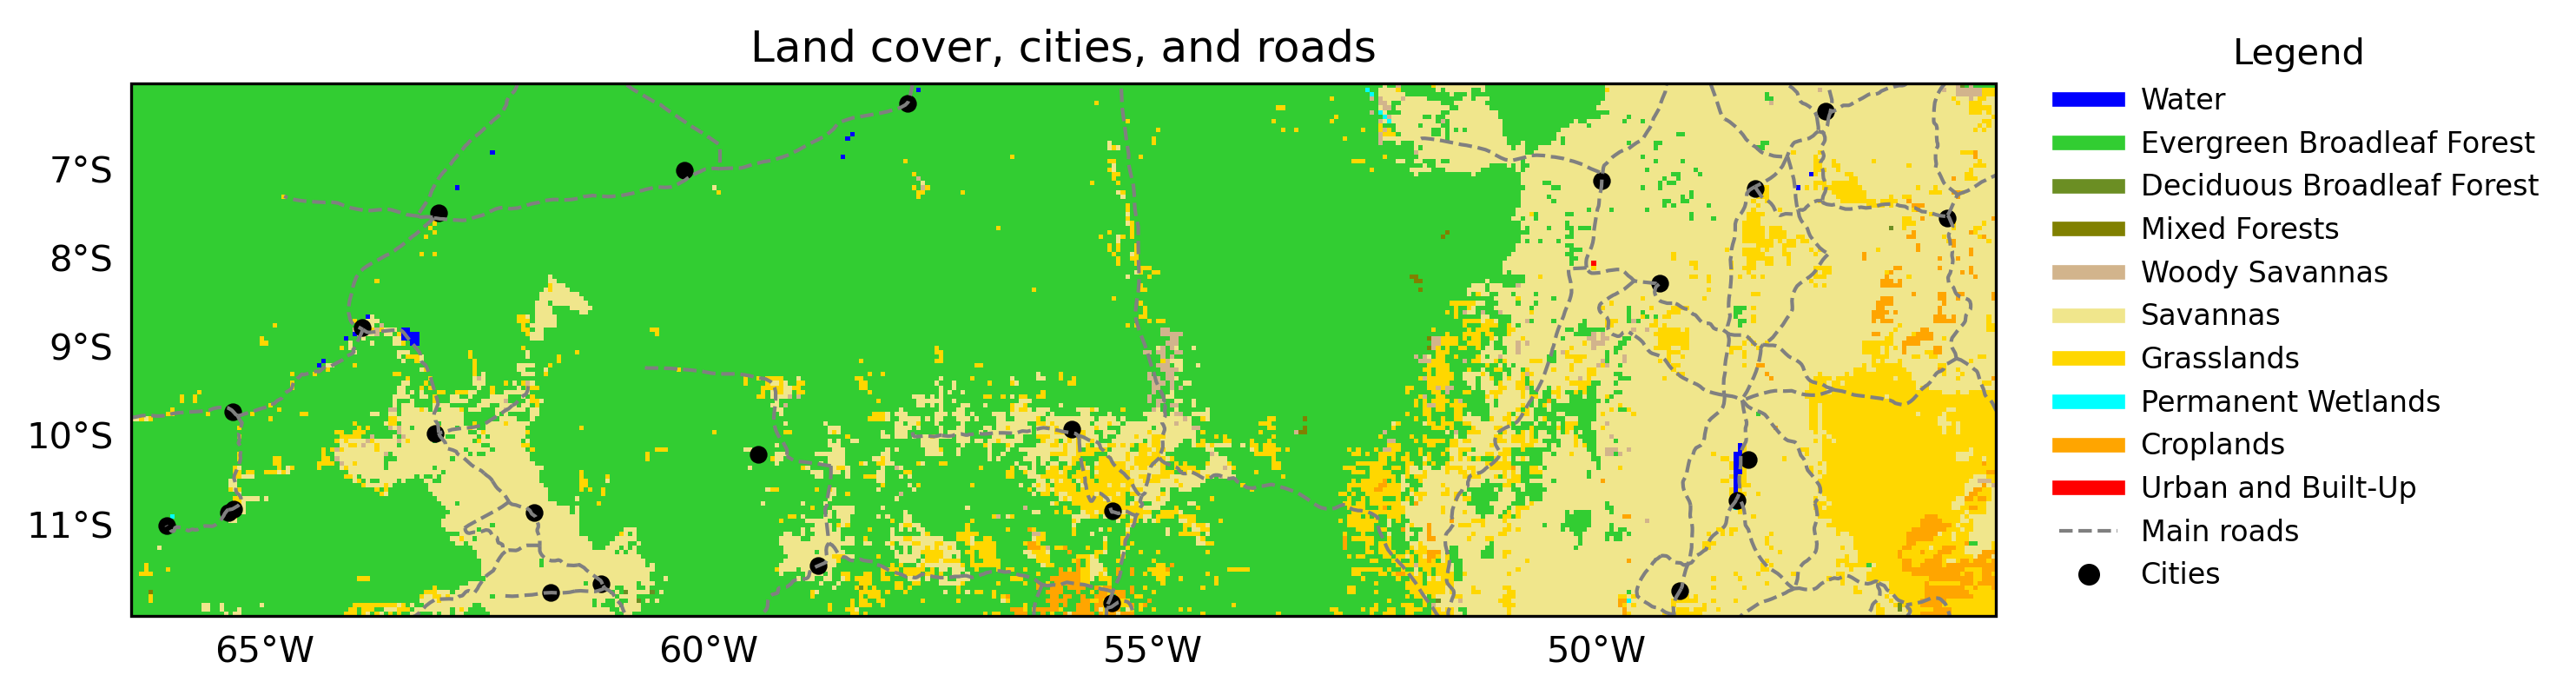

In [39]:

minlon,maxlon,minlat,maxlat,roads,cities,ds_subset,cmap,norm,filtered_colors,filtered_land_cover_classes,active_classes = var_plot_landcover()
# Create a figure and axis with a specified map projection (PlateCarree)
fig = plt.figure(figsize=(10, 3), dpi=300)  # Set figure size and resolution
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())  # Define axis with projection

# Map limits
# Set the map extent based on the predefined latitude and longitude bounds
ax.set_extent([minlon, maxlon, minlat, maxlat], crs=ccrs.PlateCarree())  # Define map's region

# Add main roadas
# Plot the main roads (from shapefile) on the map with custom line style
roads.plot(ax=ax, transform=ccrs.PlateCarree(), color="gray", linestyle="--", linewidth=1.0, label="Main roads")

# Add cities
# Scatter plot cities with specific formatting on the map
ax.scatter(
    cities.geometry.x, cities.geometry.y,  # X and Y coordinates of cities
    color="black", s=15,  # Color black and set size for city points
    transform=ccrs.PlateCarree(),  # Specify projection for the city points
    label="Cities"  # Label for the legend
)


# Add gridlines with labels
gl = ax.gridlines(draw_labels=True)  # Add gridlines to the map
gl.top_labels = gl.right_labels = False  # Disable labels at the top and right of the map
gl.bottom_labels = gl.left_labels = True  # Enable labels at the bottom and left
gl.xlines = False  # Hide the vertical gridlines
gl.ylines = False  # Hide the horizontal gridlines

# Customize the gridline intervals
gl.xlocator = mticker.MultipleLocator(5)  # Longitude labels every 5 degrees
gl.ylocator = mticker.MultipleLocator(1)  # Latitude labels every 1 degree

# Plot the land cover data on the map
plot = ds_subset["Majority_Land_Cover_Type_1"].plot(
    ax=ax,
    x="longitude",  # X-axis (longitude) for the land cover data
    y="latitude",  # Y-axis (latitude) for the land cover data
    cmap=cmap,  # Colormap for the land cover data
    norm=norm,  # Normalization for the colormap
    add_colorbar=False,  # Disable colorbar since it's not needed in this case
    zorder=0,  # Set the z-order for layering (land cover data in the background)
)

# Create custom legend handles for land cover types
# These handles represent the different filtered land cover classes in the legend
handles = [
    plt.Line2D([0], [0], color=filtered_colors[i], lw=4, label=f"{filtered_land_cover_classes[cls]}")
    for i, cls in enumerate(active_classes)  # Iterate over the active land cover classes
]

# Add additional handles for the other map features (roads, cities)
additional_handles = [
    plt.Line2D([0], [0], color="gray", lw=1.0, linestyle="--", label="Main roads"),
    plt.Line2D([0], [0], color="black", marker="o", markersize=5, linestyle="", label="Cities")
]

# Combine the legend handles for all map features
handles.extend(additional_handles)

# Add the legend to the plot
ax.legend(
    handles=handles,  # Use the combined list of handles for the legend
    loc="lower left",  # Position the legend at the bottom left
    bbox_to_anchor=(1.02, 0),  # Position the legend outside the plot to the right
    title="Legend",  # Set the title for the legend
    fontsize=8,  # Set the font size for the legend text
    title_fontsize=10,  # Set the font size for the legend title
    frameon=False  # Disable the border around the legend
)

# Add bold text to the upper-left corner of the map
#ax.text(
#    0.01, 0.99,  # Relative position in axes coordinates (0=left/bottom, 1=right/top)
#    'B)',  # Text content
#    transform=ax.transAxes,  # Use axes-relative coordinates for positioning
#    fontsize=12,  # Set font size for the annotation
#    fontweight='bold',  # Make the text bold
#    ha='left',  # Horizontal alignment to the left
#    va='top',  # Vertical alignment to the top
#)

# Set the title for the plot
plt.title("Land cover, cities, and roads")  # Set title text

# Adjust the layout to prevent overlap of plot elements
plt.tight_layout()

# Save the plot to a PNG file
#plt.savefig('filename.png')

# Display the plot
plt.show()

In [40]:
def plot_flight_track_over_landcover(
    flight_number,
    flight_date,
    ds_psap,
    save_path=None,
    step=35000,
):
    """
    Plot only the flight track over land cover (with roads/cities), and save the figure.

    Parameters
    ----------
    flight_number : str or int
    flight_date : str
    ds_psap : xarray.Dataset
        Must contain LAT_GIN and LON_GIN.
    save_path : str or None
        If None, saves to ./flight_track_landcover_<flight_number>.png
    step : int
        Subsampling step for direction arrows (quiver).
    """

    minlon, maxlon, minlat, maxlat, roads, cities, ds_subset, cmap, norm, \
        filtered_colors, filtered_land_cover_classes, active_classes = var_plot_landcover()

    fig = plt.figure(figsize=(12, 6))
    ax = fig.add_axes([0.07, 0.12, 0.72, 0.78], projection=ccrs.PlateCarree())
    ax.set_extent([minlon, maxlon, minlat, maxlat], crs=ccrs.PlateCarree())

    # --- Extract & clean coordinates (same logic as your current function) ---
    lat_valid = ds_psap["LAT_GIN"]
    lon_valid = ds_psap["LON_GIN"]

    # Filter out minimum/invalid values (your rule)
    valid_mask = (lat_valid < 0) & (lon_valid < -30)
    lat_filtered = lat_valid.where(valid_mask, drop=True)
    lon_filtered = lon_valid.where(valid_mask, drop=True)

    lat = lat_filtered.values
    lon = lon_filtered.values

    # Ensure no NaNs remain
    valid_points = (~np.isnan(lat)) & (~np.isnan(lon))
    lat = lat[valid_points]
    lon = lon[valid_points]

    # --- Plot land cover background ---
    ds_subset["Majority_Land_Cover_Type_1"].plot(
        ax=ax,
        x="longitude",
        y="latitude",
        cmap=cmap,
        norm=norm,
        add_colorbar=False,
        zorder=0,
    )

    # --- Roads + Cities ---
    roads.plot(
        ax=ax, transform=ccrs.PlateCarree(),
        color="gray", linestyle="--", linewidth=1.0, label="Main roads"
    )

    ax.scatter(
        cities.geometry.x, cities.geometry.y,
        color="black", s=15, transform=ccrs.PlateCarree(), label="Cities"
    )

    # --- Flight track line ---
    ax.plot(
        lon, lat, transform=ccrs.PlateCarree(),
        color="purple", linewidth=1.0, label="Flight track"
    )

    # --- Direction arrows (quiver) ---
    if step is not None and step > 1 and len(lon) > step:
        lon_sub = lon[::step]
        lat_sub = lat[::step]

        dx = np.diff(lon_sub)
        dy = np.diff(lat_sub)

        # midpoints for arrows
        lon_mid = lon_sub[:-1] + dx / 2
        lat_mid = lat_sub[:-1] + dy / 2

        ax.quiver(
            lon_mid, lat_mid, dx, dy,
            transform=ccrs.PlateCarree(),
            scale_units="xy", angles="xy", scale=2.5,
            color="purple", width=0.002
        )

    # --- Gridlines formatting ---
    gl = ax.gridlines(draw_labels=True)
    gl.top_labels = gl.right_labels = False
    gl.bottom_labels = gl.left_labels = True
    gl.xlines = False
    gl.ylines = False
    gl.xlocator = mticker.MultipleLocator(5)
    gl.ylocator = mticker.MultipleLocator(1)

    # --- Legend (land cover classes + roads/cities/track) ---
    landcover_handles = [
        plt.Line2D([0], [0], color=filtered_colors[i], lw=4,
                   label=f"{filtered_land_cover_classes[cls]}")
        for i, cls in enumerate(active_classes)
    ]

    additional_handles = [
        plt.Line2D([0], [0], color="gray", lw=1.0, linestyle="--", label="Main roads"),
        plt.Line2D([0], [0], color="black", marker="o", markersize=5, linestyle="", label="Cities"),
        plt.Line2D([0], [0], color="purple", lw=2.0, linestyle="-", label="Flight Track"),
    ]

    handles = landcover_handles + additional_handles

    ax.legend(
        handles=handles,
        loc="lower left",
        bbox_to_anchor=(1.02, -0.05),
        title="Legend",
        fontsize=8,
        title_fontsize=8,
        frameon=False
    )

    ax.set_title(f"Flight {flight_number} - Flight Track over Land cover")

    # --- Save ---
    if save_path is None:
        save_path = f"./flight_track_landcover_{flight_number}.png"

    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    print(f"Figure saved as {save_path}")

    return fig, ax

Figure saved as ./flight_track_landcover_b734.png
Figure saved as ./flight_track_landcover_b737.png


KeyboardInterrupt: 

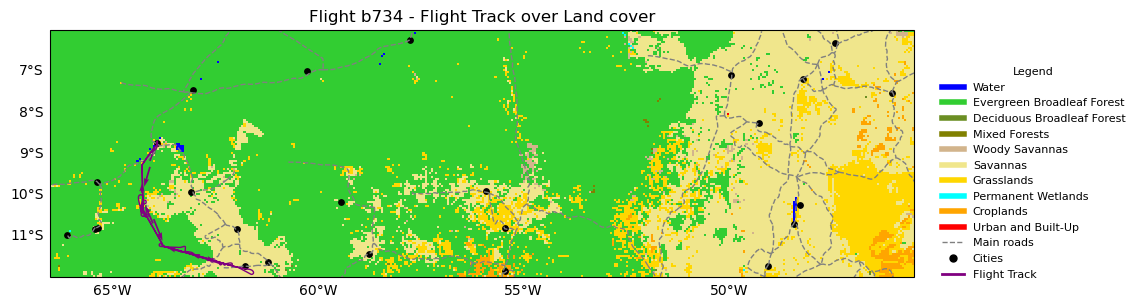

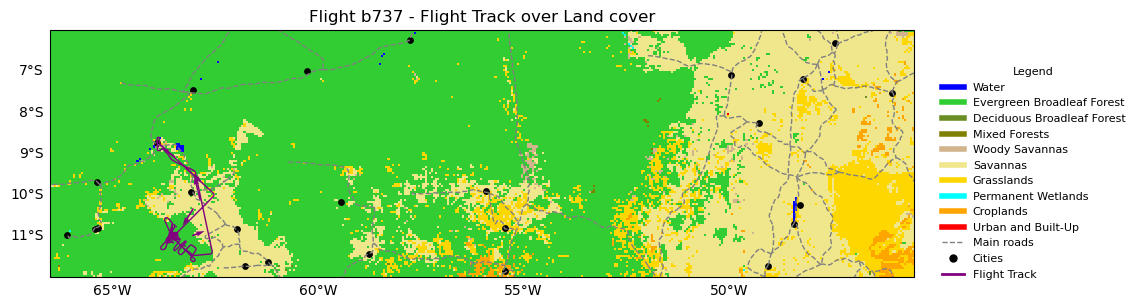

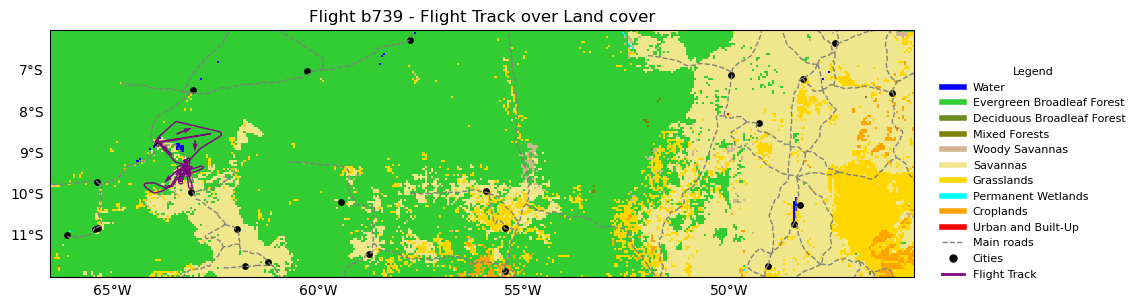

In [41]:
# Iterate over all matching flights
for nc_file in filtered_nc:


    ds_core = xr.open_dataset(nc_file)

    # Extract the flight number (b###) from the file path
    match = re.search(r'b\d{3}', nc_file)  # Looks for 'b' followed by 3 digits
    flight_number = match.group(0) if match else "Unknown"
    # Extract the date in yyyymmdd format
    date_match = re.search(r'(\d{8})', nc_file)
    if date_match:
        date_str = date_match.group(1)
        flight_date = datetime.strptime(date_str, "%Y%m%d").strftime("%Y-%m-%d")
    else:
        flight_date = "Unknown"


    plot_flight_track_over_landcover( 
        flight_number=flight_number,
        flight_date = flight_date,
        ds_psap=ds_core)



In [36]:
def make_landcover_basemap(figsize=(12, 6)):
    minlon, maxlon, minlat, maxlat, roads, cities, ds_subset, cmap, norm, \
        filtered_colors, filtered_land_cover_classes, active_classes = var_plot_landcover()

    fig = plt.figure(figsize=figsize)
    ax = fig.add_axes([0.07, 0.12, 0.72, 0.78], projection=ccrs.PlateCarree())
    ax.set_extent([minlon, maxlon, minlat, maxlat], crs=ccrs.PlateCarree())

    # Land cover background
    ds_subset["Majority_Land_Cover_Type_1"].plot(
        ax=ax, x="longitude", y="latitude",
        cmap=cmap, norm=norm,
        add_colorbar=False,
        zorder=0,
    )

    # Roads + cities
    roads.plot(ax=ax, transform=ccrs.PlateCarree(),
               color="gray", linestyle="--", linewidth=1.0, label="Main roads")

    ax.scatter(cities.geometry.x, cities.geometry.y,
               color="black", s=15, transform=ccrs.PlateCarree(), label="Cities")

    # Gridlines
    gl = ax.gridlines(draw_labels=True)
    gl.top_labels = gl.right_labels = False
    gl.bottom_labels = gl.left_labels = True
    gl.xlines = False
    gl.ylines = False
    gl.xlocator = mticker.MultipleLocator(5)
    gl.ylocator = mticker.MultipleLocator(1)

    # Land-cover legend handles (we’ll add tracks later)
    landcover_handles = [
        plt.Line2D([0], [0], color=filtered_colors[i], lw=4,
                   label=f"{filtered_land_cover_classes[cls]}")
        for i, cls in enumerate(active_classes)
    ]

    base_handles = landcover_handles + [
        plt.Line2D([0], [0], color="gray", lw=1.0, linestyle="--", label="Main roads"),
        plt.Line2D([0], [0], color="black", marker="o", markersize=5, linestyle="", label="Cities"),
        plt.Line2D([0], [0], color="purple", lw=2.0, linestyle="-", label="Flight Track"),
    ]

    return fig, ax, base_handles


def add_flight_track(
    ax,
    ds_psap,
    flight_number,
    color="purple",
    linewidth=2.5,
    label_offset=0.02,
):
    lat_valid = ds_psap["LAT_GIN"]
    lon_valid = ds_psap["LON_GIN"]

    # Your validity rule
    valid_mask = (lat_valid < 0) & (lon_valid < -30)
    lat_filtered = lat_valid.where(valid_mask, drop=True).values
    lon_filtered = lon_valid.where(valid_mask, drop=True).values

    # Remove NaNs
    ok = (~np.isnan(lat_filtered)) & (~np.isnan(lon_filtered))
    lat = lat_filtered[ok]
    lon = lon_filtered[ok]

    if len(lon) < 2:
        return

    # --- Plot thicker flight track ---
    ax.plot(
        lon,
        lat,
        transform=ccrs.PlateCarree(),
        color=color,
        linewidth=linewidth,
        zorder=3,
    )

    # --- Add flight number label along the track ---
    mid_idx = len(lon) // 2
    ax.text(
        lon[mid_idx],
        lat[mid_idx] + label_offset,
        flight_number,
        transform=ccrs.PlateCarree(),
        fontsize=9,
        fontweight="bold",
        color=color,
        ha="center",
        va="bottom",
        zorder=4,
        path_effects=[
            patheffects.withStroke(linewidth=2, foreground="white")
        ],
    )


Figure saved as ./all_flights_tracks_landcover.png


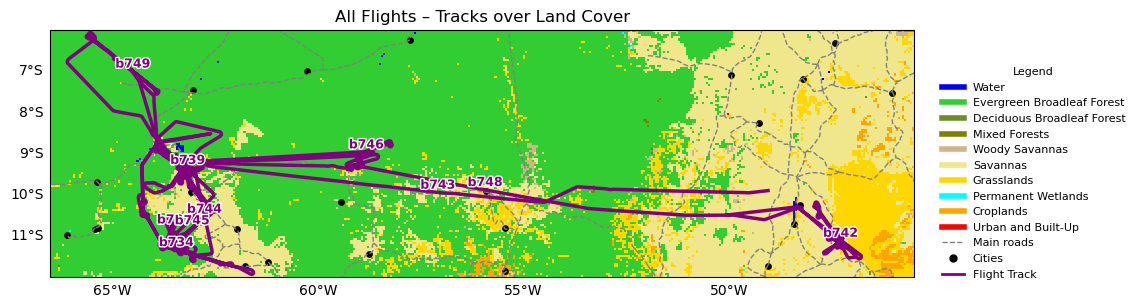

In [42]:
fig, ax, base_handles = make_landcover_basemap(figsize=(12, 6))

for nc_file in filtered_nc:
    ds_core = xr.open_dataset(nc_file)

    match = re.search(r"b\d{3}", nc_file)
    flight_number = match.group(0) if match else "Unknown"

    add_flight_track(ax=ax, ds_psap=ds_core, flight_number=flight_number,
                     color="purple", linewidth=2.5)

ax.set_title("All Flights – Tracks over Land Cover")

# ✅ Legend call (this is what was missing)
ax.legend(
    handles=base_handles,
    loc="lower left",
    bbox_to_anchor=(1.02, -0.05),
    title="Legend",
    fontsize=8,
    title_fontsize=8,
    frameon=False,
)

plt.savefig("./all_flights_tracks_landcover.png", dpi=300, bbox_inches="tight")
print("Figure saved as ./all_flights_tracks_landcover.png")
